In [ ]:
import pandas as pd
import numpy as np

In [ ]:
data = pd.read_csv('credit_risk_dataset.csv')

In [ ]:
data.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [ ]:
data.tail()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26
32580,66,42000,RENT,2.0,MEDICAL,B,6475,9.99,0,0.15,N,30


In [ ]:
data.shape

(32581, 13)

In [ ]:
data.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')

In [ ]:
data.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


**Data Cleaning**

In [ ]:
categorical_col = [
    "person_home_ownership",
    "loan_intent",
    "loan_grade"
]

for col in categorical_col:
  data[col] = data[col].astype("category")

In [ ]:
data['cb_person_default_on_file'] = data['cb_person_default_on_file'].map({"Y": 1, "N" : 0})
data['cb_person_default_on_file'] = data['cb_person_default_on_file'].astype("int64")

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   person_age                  32581 non-null  int64   
 1   person_income               32581 non-null  int64   
 2   person_home_ownership       32581 non-null  category
 3   person_emp_length           31686 non-null  float64 
 4   loan_intent                 32581 non-null  category
 5   loan_grade                  32581 non-null  category
 6   loan_amnt                   32581 non-null  int64   
 7   loan_int_rate               29465 non-null  float64 
 8   loan_status                 32581 non-null  int64   
 9   loan_percent_income         32581 non-null  float64 
 10  cb_person_default_on_file   32581 non-null  int64   
 11  cb_person_cred_hist_length  32581 non-null  int64   
dtypes: category(3), float64(3), int64(6)
memory usage: 2.3 MB


In [ ]:
data.isnull().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,895
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3116
loan_status,0
loan_percent_income,0


In [ ]:
# Not mean because it gets affected by extreme values(outliers) and not mode because it is for categorical data
data['loan_int_rate'] = data['loan_int_rate'].fillna(data['loan_int_rate'].median())
data['person_emp_length'] = data['person_emp_length'].fillna(data['person_emp_length'].median())

In [ ]:
data.isnull().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,0
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,0
loan_status,0
loan_percent_income,0


**Exploratory Data Analysis (EDA)**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

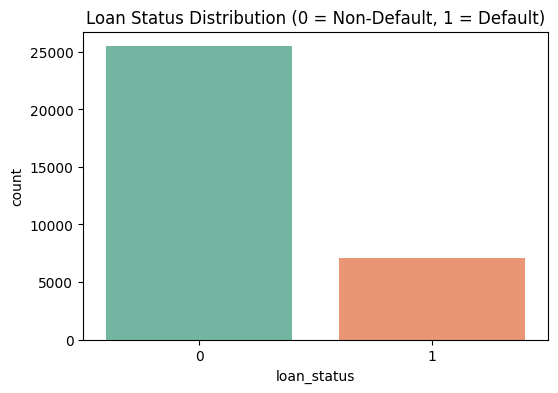

In [ ]:
# Loan Status distribution
plt.figure(figsize=(6,4))
sns.countplot(data=data, x="loan_status", hue="loan_status", palette="Set2", legend=False)
plt.title("Loan Status Distribution (0 = Non-Default, 1 = Default)")
plt.show()

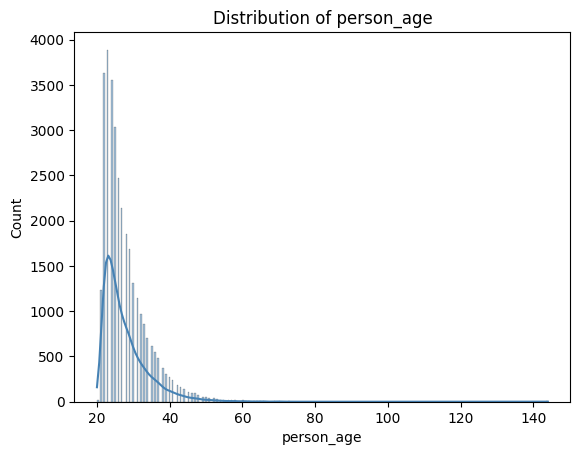

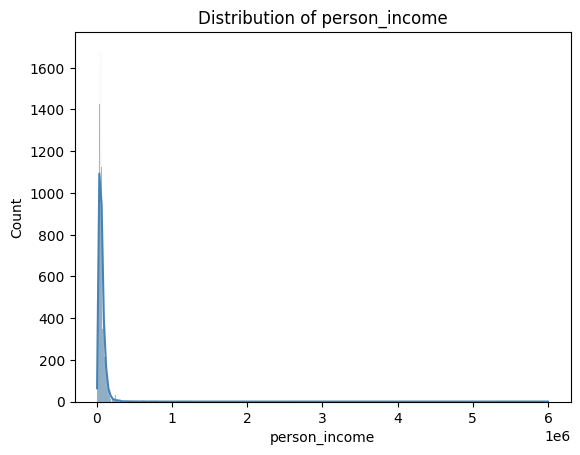

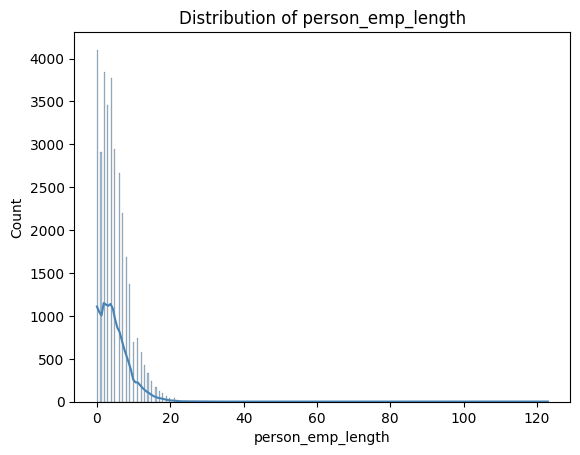

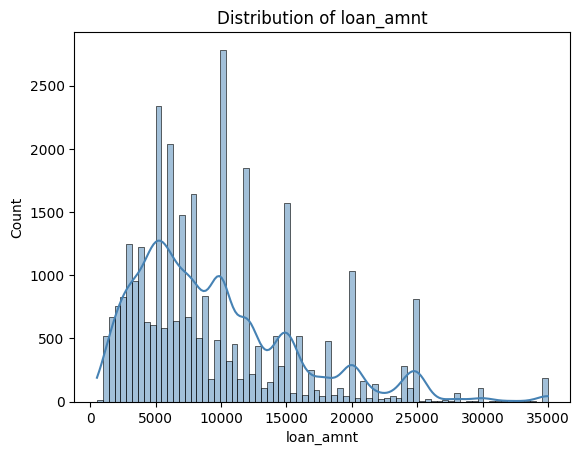

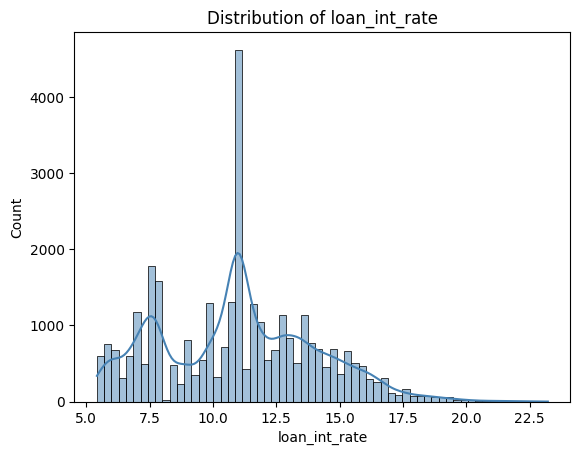

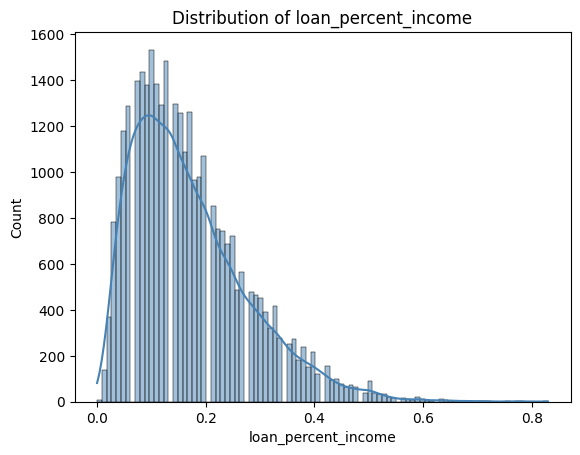

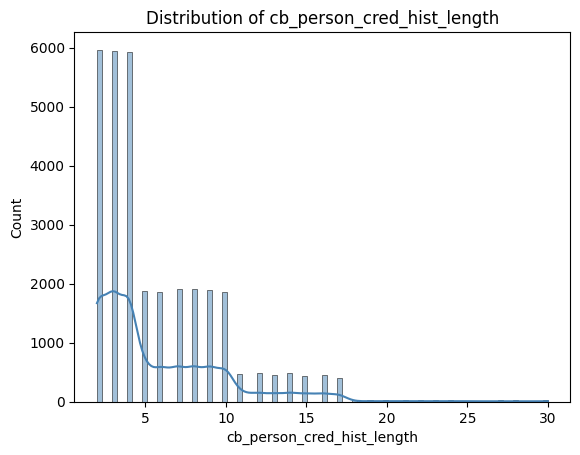

In [ ]:
# Univariate Analysis (Numerical features)

num_cols = ['person_age', 'person_income', 'person_emp_length',
            'loan_amnt', 'loan_int_rate', 'loan_percent_income',
            'cb_person_cred_hist_length']

for col in num_cols:
  plt.plot(figsize = (5,3))
  sns.histplot(data[col],kde=True,color="steelblue")
  plt.title(f"Distribution of {col}")
  plt.show()

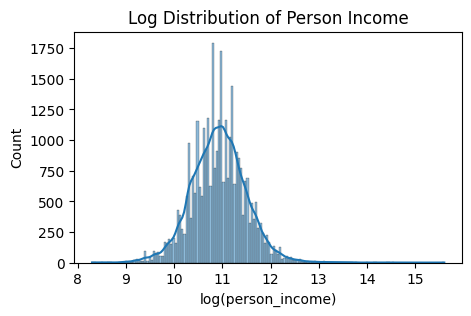

In [ ]:
data["log_person_income"] = np.log1p(data["person_income"])

plt.figure(figsize=(5,3))
sns.histplot(data["log_person_income"], kde=True)
plt.title("Log Distribution of Person Income")
plt.xlabel("log(person_income)")
plt.show()

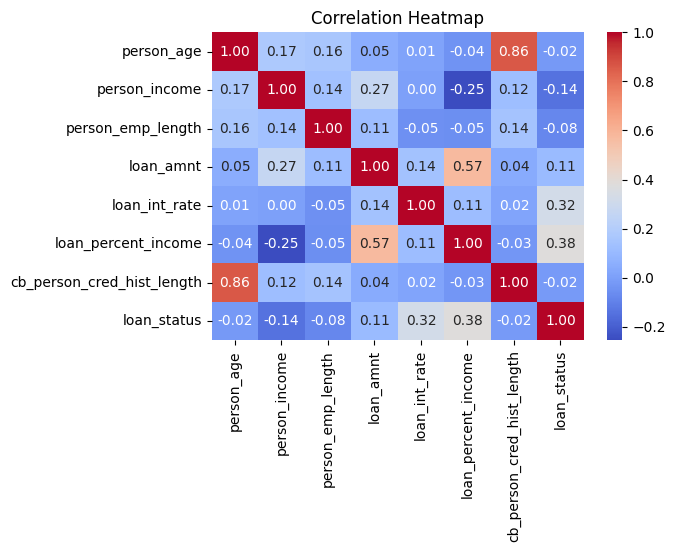

In [ ]:
# Correlation heatmap (Numerical only)
plt.figure(figsize = (6,4))
sns.heatmap(data[num_cols + ["loan_status"]].corr(),annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
print("\n🔹 Default % by Loan Grade:")
print(pd.crosstab(data['loan_grade'], data['loan_status'], normalize='index') * 100)


🔹 Default % by Loan Grade:
loan_status          0          1
loan_grade                       
A            90.043611   9.956389
B            83.724046  16.275954
C            79.266027  20.733973
D            40.954220  59.045780
E            35.580913  64.419087
F            29.460581  70.539419
G             1.562500  98.437500


In [ ]:
print("\n🔹 Default % by Loan Intent:")
print(pd.crosstab(data['loan_intent'], data['loan_status'], normalize='index') * 100)


🔹 Default % by Loan Intent:
loan_status                0          1
loan_intent                            
DEBTCONSOLIDATION  71.412126  28.587874
EDUCATION          82.783202  17.216798
HOMEIMPROVEMENT    73.897365  26.102635
MEDICAL            73.299292  26.700708
PERSONAL           80.112298  19.887702
VENTURE            85.189718  14.810282


In [ ]:
data.to_csv("credit_risk_cleaned_dataset.csv",index = False)